# Data Prep – B0005

Loads the raw `.mat` file, pulls out discharge cycles and saves them as CSVs.
Also saves the assumed physical constants and does some basic EDA plots.


In [ ]:
import os
import glob
import scipy.io as sio
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
raw_file = "../data/raw/B0005.mat"
mat = sio.loadmat(raw_file)

# [0,0] is just how scipy unpacks MATLAB structs
battery = mat['B0005'][0, 0]
all_cycles = battery['cycle'][0]

print("total cycles:", len(all_cycles))


total cycles: 616


In [ ]:
# helper to unpack one cycle struct into a DataFrame
def get_cycle_df(cyc, cyc_num):
    d = cyc['data'][0, 0]
    df = pd.DataFrame({
        'time_s':      d['Time'][0],
        'current_A':   d['Current_measured'][0],
        'voltage_V':   d['Voltage_measured'][0],
        'temp_C':      d['Temperature_measured'][0],
        'cycle_num':   cyc_num,   # keeping track so groupby works later
    })
    return df


In [ ]:
out_dir = "../data/processed"
os.makedirs(out_dir, exist_ok=True)

saved = []

for idx, cyc in enumerate(all_cycles):
    if cyc['type'][0] != 'discharge':
        continue

    df_cyc = get_cycle_df(cyc, idx + 1)

    # one CSV per cycle – easier to load individually later
    fpath = f"{out_dir}/B0005_cycle_{idx+1}.csv"
    df_cyc.to_csv(fpath, index=False)
    saved.append(fpath)

print(f"{len(saved)} discharge cycles saved to '{out_dir}'")


168 discharge cycles saved to '../data/processed'


In [ ]:
# save the physical constants we're assuming
# easier to update here than to hunt through later notebooks
assumptions = {
    'battery_type': '18650 Li-ion (NMC)',
    'mass_kg': 0.045,
    'Cp_J_per_kgK': 900,
    'surface_area_m2': 0.021,
    'note': 'h and R fitted per cycle, not fixed',
    'source': 'literature + week 1 fits',
}

os.makedirs("../data/meta", exist_ok=True)
pd.DataFrame([assumptions]).to_csv("../data/meta/assumptions.csv", index=False)
print("assumptions saved")


assumptions saved


In [ ]:
# reload all the CSVs into one big DataFrame for analysis
csv_files = sorted(glob.glob("../data/processed/B0005_cycle_*.csv"))
df_all = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

print(f"{len(df_all)} rows, {df_all['cycle_num'].nunique()} cycles")
df_all.head()


50285 rows, 168 cycles


,time_s,current_A,voltage_V,temp_C,cycle_num
0,0.000,-0.007981,4.188299,24.524797,10
1,16.719,0.001701,4.187385,24.518700,10
2,35.656,-2.014020,3.982253,24.571624,10
3,53.859,-2.011235,3.960321,24.716236,10
4,72.000,-2.011086,3.944281,24.891964,10


In [ ]:
# per-cycle stats – handy for spotting outlier cycles before modelling
cycle_duration = df_all.groupby('cycle_num')['time_s'].max()
max_temp = df_all.groupby('cycle_num')['temp_C'].max()
max_current = df_all.groupby('cycle_num')['current_A'].max()
avg_current = df_all.groupby('cycle_num')['current_A'].mean()


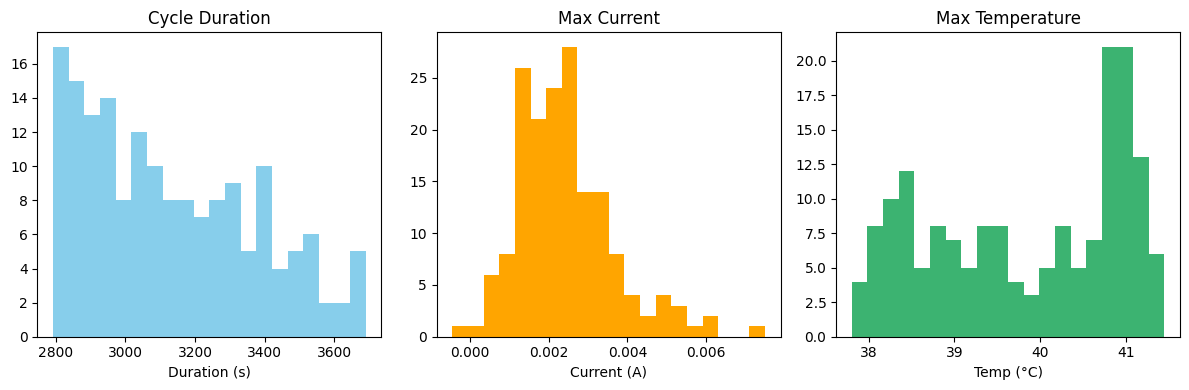

In [ ]:
# distribution of key metrics across all cycles
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

ax1.hist(cycle_duration, bins=20, color='skyblue')
ax1.set_title('Cycle Duration')
ax1.set_xlabel('Duration (s)')

ax2.hist(max_current, bins=20, color='orange')
ax2.set_title('Max Current')
ax2.set_xlabel('Current (A)')

ax3.hist(max_temp, bins=20, color='mediumseagreen')
ax3.set_title('Max Temperature')
ax3.set_xlabel('Temp (°C)')

plt.tight_layout()
plt.show()


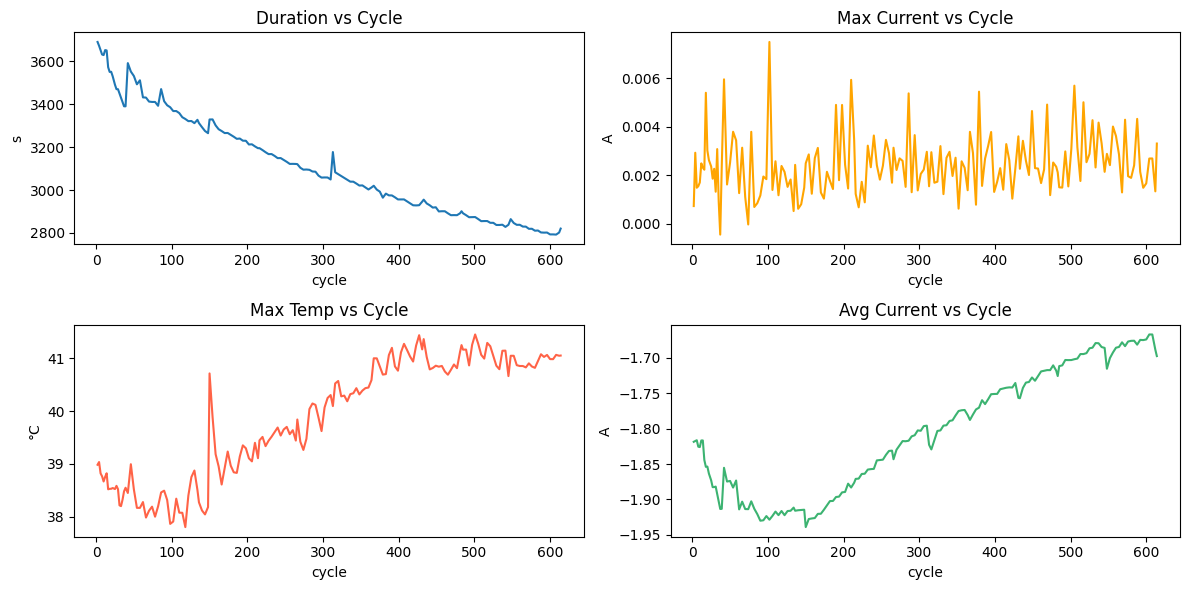

In [ ]:
# how do these metrics change over the battery lifetime?
# duration dropping = capacity fade = battery aging
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

cycle_duration.plot(ax=axes[0, 0])
axes[0, 0].set_title('Duration vs Cycle')
axes[0, 0].set_ylabel('s')

max_current.plot(ax=axes[0, 1], color='orange')
axes[0, 1].set_title('Max Current vs Cycle')
axes[0, 1].set_ylabel('A')

max_temp.plot(ax=axes[1, 0], color='tomato')
axes[1, 0].set_title('Max Temp vs Cycle')
axes[1, 0].set_ylabel('°C')

avg_current.plot(ax=axes[1, 1], color='mediumseagreen')
axes[1, 1].set_title('Avg Current vs Cycle')
axes[1, 1].set_ylabel('A')

for ax in axes.flat:
    ax.set_xlabel('cycle')

plt.tight_layout()
plt.show()


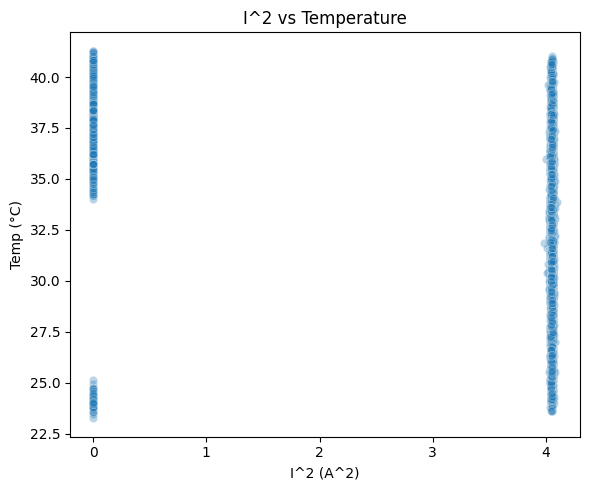

In [ ]:
# check whether I^2 and temperature are correlated
# they should be if joule heating (Q = I^2 * R) is the main heat source
df_sample = df_all.sample(5000, random_state=42)  # sample so it's not slow

plt.figure(figsize=(6, 5))
sns.scatterplot(x=df_sample['current_A']**2, y=df_sample['temp_C'], alpha=0.3)
plt.xlabel('I^2 (A^2)')
plt.ylabel('Temp (°C)')
plt.title('I^2 vs Temperature')
plt.tight_layout()
plt.show()
